# Experiment 2 (MNIST): Lipschitz Estimation on Real Classifiers

## Motivation and relation to Experiment 1

Experiment 1 (`toy_lipschitz`, sibling folder) built three ways to estimate
a function's **Lipschitz constant** `L` -- how much its output can change
for a given change in input, `|f(x')-f(x)| <= L * ||x'-x||` -- and
validated all three against a **known, closed-form ground truth** `L*` on
a toy 1D/2D regression problem. It also showed that replacing plain
Euclidean distance with a **Mahalanobis distance** fit from the data
itself can substantially change (and, there, improve) the resulting
estimate.

This experiment scales the same three estimators up to real classifiers
trained on MNIST. **There is no closed-form `L*` here** -- a trained
neural network's exact Lipschitz constant is not analytically knowable in
general. So this experiment cannot ask "how close is the estimate to the
truth"; it can only ask two weaker but still meaningful questions:

1. **Do the three independent sub-methods (pairwise, local-perturbation,
   gradient-norm) roughly agree with each other?** Disagreement doesn't
   necessarily mean a bug (see this notebook's results below -- it turns
   out they *don't* agree well here, and that's a real, reportable
   finding, not an error), but it tells you how much to trust any single
   number.
2. **Is the estimate stable under resampling?** An estimate that swings
   wildly depending on which random subset of the data it was computed
   from is fitting sampling noise, not a real property of the model.

These two checks -- sub-method agreement and subsample stability --
replace Experiment 1's "compare to `L*`" checkpoint everywhere in this
notebook.

**Out of scope for this experiment** (may return in a later one):
adversarial examples, FGSM/PGD attacks, robustness mitigations (weight
decay, spectral norm, gradient penalty, adversarial training, input
smoothing), Fashion-MNIST.

## What's being measured

Instead of a scalar regression output `f(x)` (Experiment 1), a classifier
outputs 10 logits. The Lipschitz estimators here are applied to the
**margin function**, `margin(x) = logit[y_true] - max(logit[j] for j !=
y_true)` -- the natural classifier analogue of a scalar output, and the
quantity robustness actually depends on: the margin crossing zero is
exactly where the predicted class flips.

Three classifiers are trained (logistic regression, a small MLP, a small
CNN), and for each, all three sub-methods are computed twice: once under
plain Euclidean distance, once under a **ridge-regularized Mahalanobis
distance** fit from MNIST's own pixel covariance (raw pixel covariance is
exactly singular -- many border pixels are 0 in every image -- so it must
be regularized before it can be inverted; how much regularization to use
is itself selected by a data-driven sweep, mirroring Experiment 1's
polynomial-embedding-degree selection).

This is a thin driver notebook -- all reusable logic lives in the sibling
`.py` modules (`data.py`, `models.py`, `estimators.py`, `distance.py`,
`run_experiment.py`, `plots.py`); this notebook only calls into them and
displays the results. See `README.md` in this folder for a plain
file-by-file reference of the codebase and the full write-up of what was
found.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from mnist_lipschitz import run_experiment, plots

## Running the full experiment

`run_mnist_experiment()` runs, in order:

1. **Train** logistic regression, MLP, and a small CNN on full MNIST.
2. **Euclidean-distance estimates**: all three sub-methods (pairwise,
   local-perturbation, gradient-norm), on all three models, evaluated on a
   fixed set of held-out test points.
3. **Epsilon selection**: fit the full-training-set pixel covariance,
   sweep several candidate ridge strengths (`epsilon`), and pick the
   smallest one whose regularized covariance is well-conditioned *and*
   whose resulting estimate is stable across independent random
   subsamples of the training data.
4. **Mahalanobis-distance estimates**: the same three sub-methods on the
   same three models, now under the selected Mahalanobis distance.
5. **Save** everything to `results/` (`mnist_experiment_results.json` for
   scalar summaries, `mnist_experiment_arrays.npz` for the full per-point
   arrays).

This takes about a minute on CPU.

In [3]:
results = run_experiment.run_mnist_experiment()

=== Step 1: training models ===


  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


...

  mlp: pairwise=1.1760  local_max=0.3674  grad_max=16.0362  grad_mean=9.6752


  cnn: pairwise=1.1220  local_max=0.1897  grad_max=9.7031  grad_mean=5.3170

=== Step 4b: Mahalanobis ratio-distribution analysis (epsilon=0.01, all models) ===


  [mahalanobis/logistic_regression] all-pairs ratio:        mean=0.1389  max=1.2492  n=499500
  [mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.1078  max=1.0980  n=5000


  [mahalanobis/mlp] all-pairs ratio:        mean=0.1870  max=1.1762  n=499500
  [mahalanobis/mlp] near-neighbor ratio:     mean=0.1537  max=0.9965  n=5000


  [mahalanobis/cnn] all-pairs ratio:        mean=0.1983  max=1.1682  n=499500
  [mahalanobis/cnn] near-neighbor ratio:     mean=0.1508  max=0.8452  n=5000

Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results


## Model accuracies

Sanity check before looking at any Lipschitz numbers: did training
actually work? (Thresholds validated in `tests/test_models.py`: logistic
regression > 90%, MLP > 96%, CNN > 98%, each with headroom below what's
typically observed.)

In [4]:
for name, acc in results["accuracies"].items():
    print(f"{name:20s} train_acc={acc['train']:.4f}  test_acc={acc['test']:.4f}")

logistic_regression  train_acc=0.9287  test_acc=0.9270
mlp                  train_acc=0.9931  test_acc=0.9782
cnn                  train_acc=0.9889  test_acc=0.9865


## Euclidean-distance estimates: do the three sub-methods agree?

Plain Euclidean distance in raw pixel space, for all three models. Each
panel below is one model; the three bars are the three independently
implemented sub-methods, on a log scale (they live on very different
natural scales here, which is itself part of the finding).

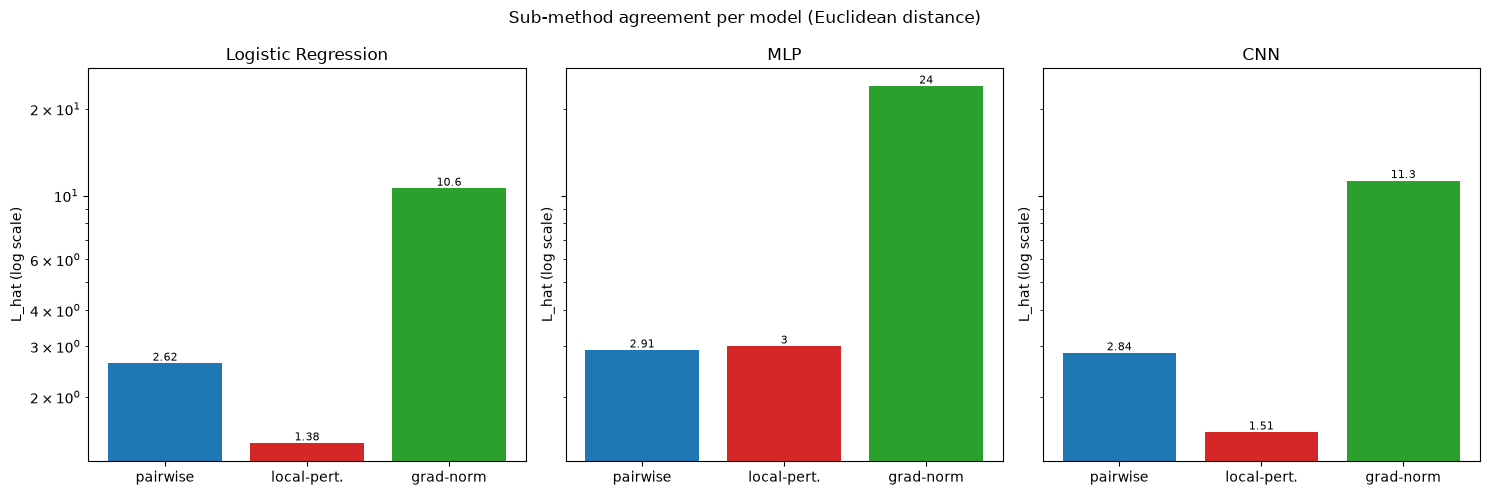

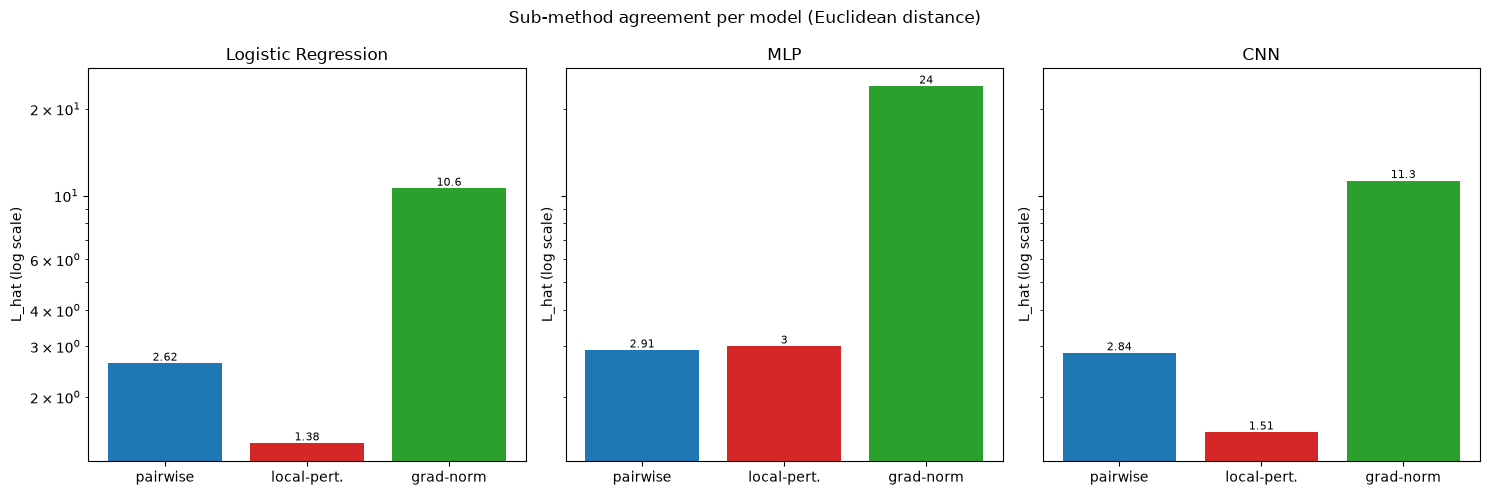

In [5]:
fig_agree_euclidean = plots.plot_submethod_agreement(
    results["euclidean_results"], metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_euclidean.png")
display(fig_agree_euclidean)

## Epsilon selection

MNIST's raw pixel covariance is exactly singular (constant-zero border
pixels), so it can't be inverted directly. The plot below shows, across a
range of candidate `epsilon` values (log scale): the condition number of
the ridge-regularized covariance (should shrink as epsilon grows -- always
true, this is a deterministic mathematical fact) and the coefficient of
variation of the resulting estimate across independent random subsamples
of the training set (should not get *worse* as epsilon grows -- this one
is an empirical check, not a mathematical guarantee, and is where a real
implementation bug would show up first). The selected epsilon (dashed
line) is the smallest one meeting both a condition-number bound and a
stability bound.

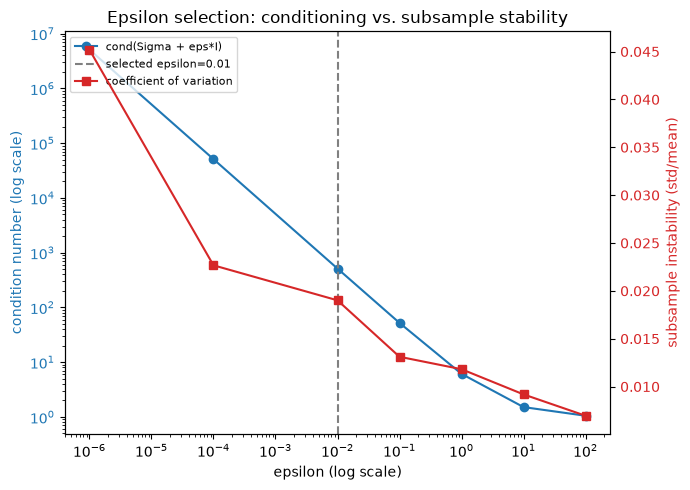

selected epsilon = 0.01


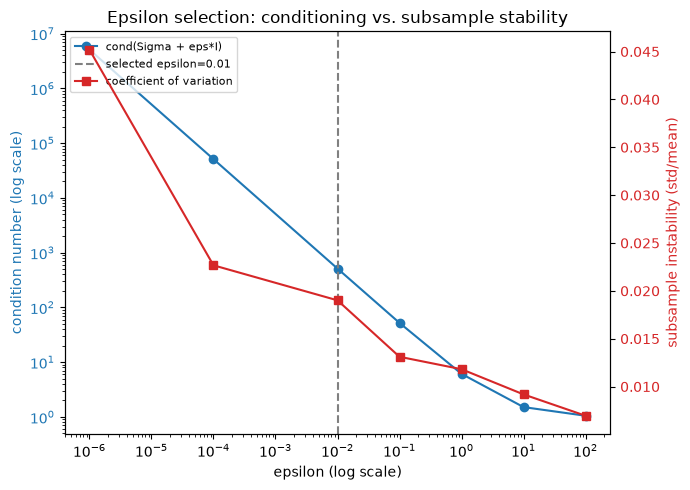

In [6]:
fig_epsilon = plots.plot_epsilon_sweep(
    results["epsilon_values"], results["cond_numbers"], results["cv_values"],
    selected_epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "epsilon_sweep.png")
display(fig_epsilon)
print(f"selected epsilon = {results['selected_epsilon']:g}")

## Why regularization is needed: the covariance's eigenvalue spectrum

The epsilon sweep above is a downstream *consequence* of a more basic
fact: MNIST's raw pixel covariance `Sigma` is singular. This section
makes that directly visible by plotting `Sigma`'s eigenvalue spectrum
(sorted largest to smallest, log scale), together with the
ridge-regularized spectrum `Sigma + epsilon*I` at the epsilon selected
above.

`Sigma + epsilon*I` has the *same eigenvectors* as `Sigma` -- adding
`epsilon*I` only shifts every eigenvalue up by exactly `epsilon` -- so the
two curves below differ only where `epsilon` actually matters: once an
eigenvalue of `Sigma` drops below `epsilon`, the regularized curve
flattens out at `epsilon` instead of continuing to fall, which is exactly
what keeps `(Sigma + epsilon*I)^{-1}` (the precision matrix used for
Mahalanobis distance) from blowing up in those directions.

largest eigenvalue:  5.1169
smallest eigenvalue: 6.1375e-34
eigenvalues below 1e-6: 94 / 784


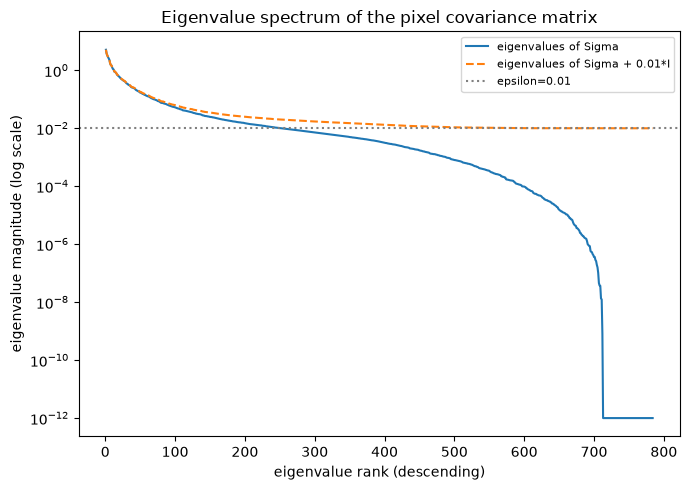

In [7]:
eigenvalues = results["covariance_eigenvalues"]
fig_eigenvalues = plots.plot_covariance_eigenvalues(
    eigenvalues, epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "covariance_eigenvalues.png")

n_near_zero = (eigenvalues < 1e-6).sum().item()
print(f"largest eigenvalue:  {eigenvalues[0].item():.4f}")
print(f"smallest eigenvalue: {eigenvalues[-1].item():.4e}")
print(f"eigenvalues below 1e-6: {n_near_zero} / {len(eigenvalues)}")

## Mahalanobis vs. Euclidean: does the metric change the estimates?

This is the central question of the experiment -- the same question
Experiment 1 asked on the toy problem, now on real classifiers. Same
three models, same three sub-methods, only the distance metric changes.

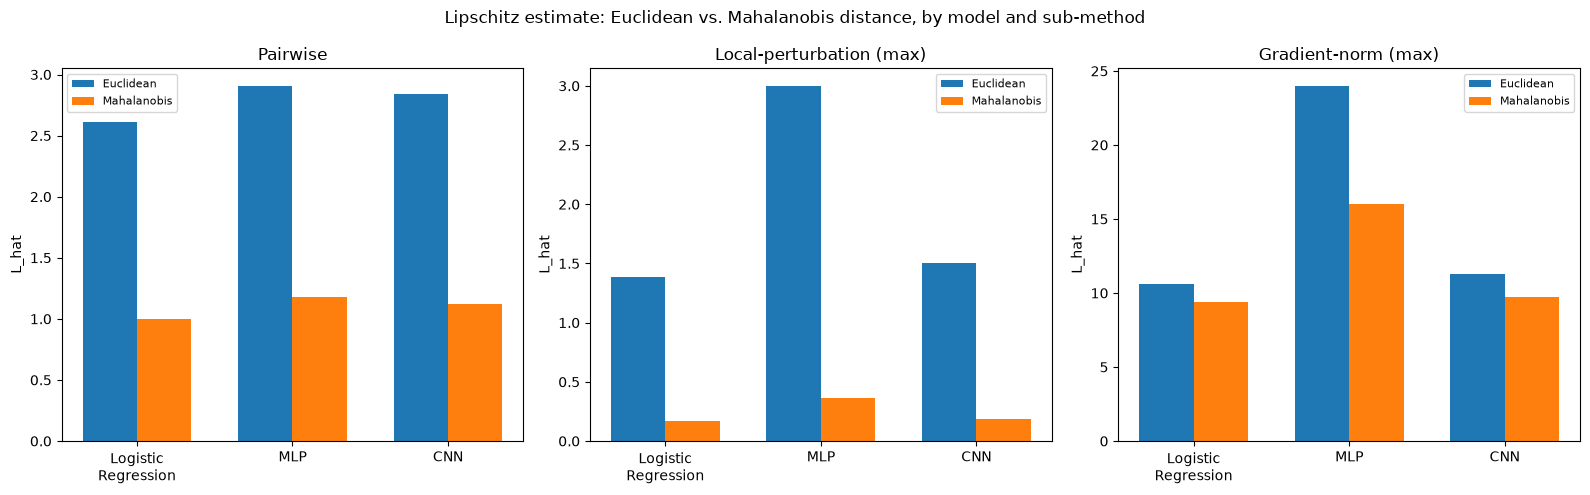

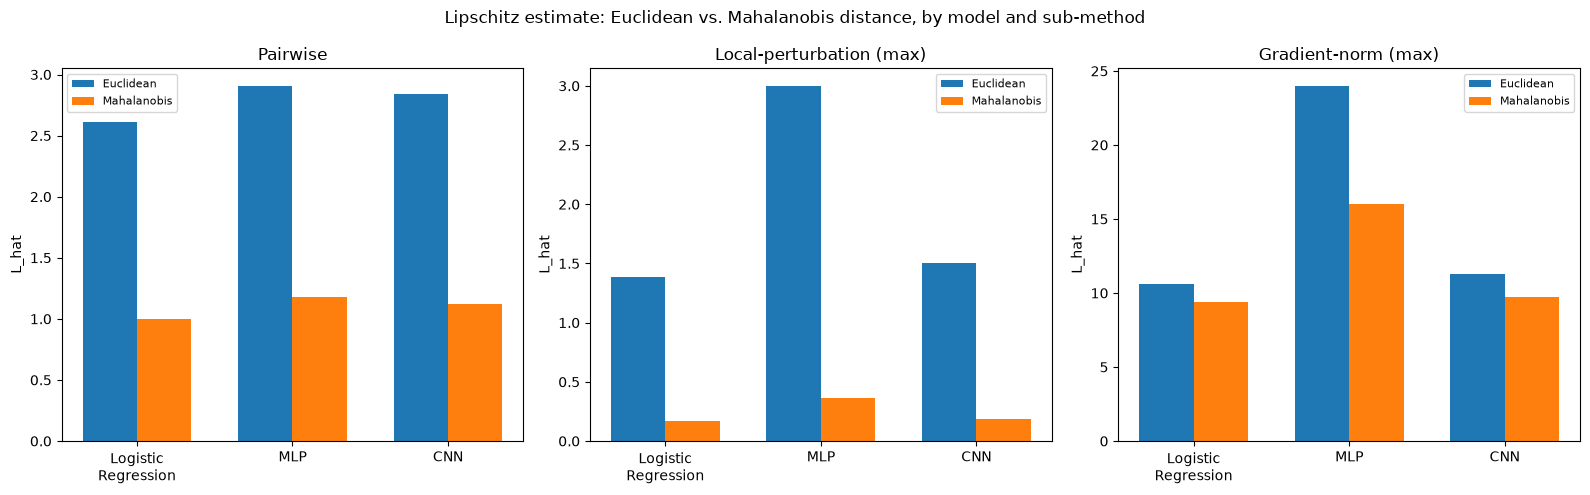

In [8]:
fig_compare = plots.plot_euclidean_vs_mahalanobis(
    results["euclidean_results"], results["mahalanobis_results"],
    save_path=run_experiment.RESULTS_DIR / "euclidean_vs_mahalanobis.png")
display(fig_compare)

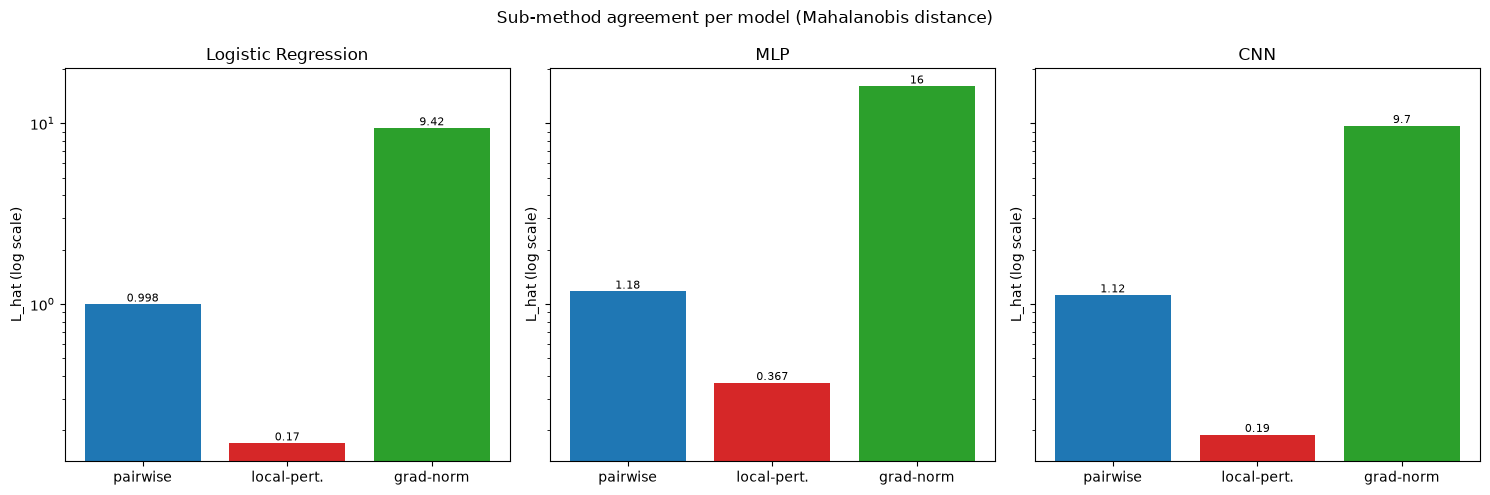

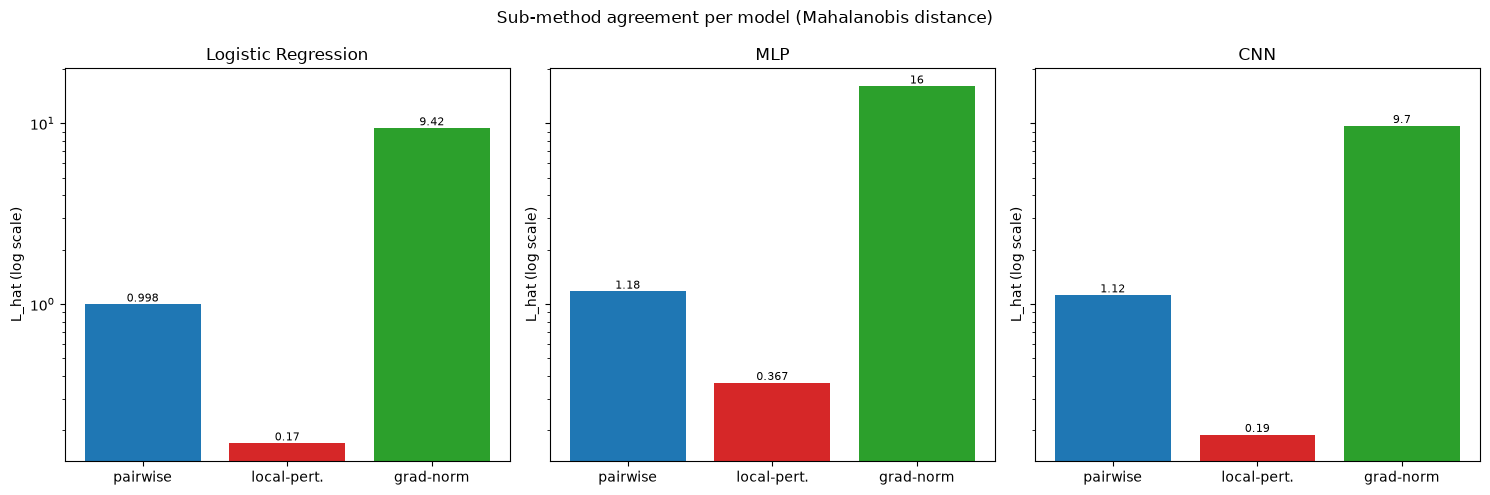

In [9]:
fig_agree_mahalanobis = plots.plot_submethod_agreement(
    results["mahalanobis_results"], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_mahalanobis.png")
display(fig_agree_mahalanobis)

## Ratio distribution and near-neighbour pairs

Every checkpoint above looks at a single summary number per model/metric
-- a max (`pairwise`), or a max/mean over a few hundred points. This
checkpoint instead looks at the full **distribution** of pairwise ratios,
`|margin_i - margin_j| / distance(x_i, x_j)`, computed over all pairs in
a **stratified sample** of 1000 test points (roughly 100 per digit, so no
class dominates by chance) that's disjoint from the 300-point sample used
above.

It then asks a more specific question: does that distribution look
different when restricted to **near-neighbour** pairs -- points that are
actually close together in raw pixel space (5-nearest-neighbours), rather
than arbitrary pairs of digits that may look nothing alike? This matters
because adversarial-style local stretch is a *local* phenomenon: the
ratio between two visually unrelated digits (a 1 and an 8 on opposite
sides of pixel space) says little about how sensitive the model is to a
*small* perturbation, whereas the ratio between two visually similar
images is closer to what a local Lipschitz constant is actually meant to
capture.

This is now run for **all three models**, under **Euclidean distance**.
The Mahalanobis distance is a planned follow-up, reusing the
epsilon/precision already selected below (Epsilon selection) rather than
re-running epsilon selection.

In [10]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 2b),
# for all three models -- run_ratio_distribution_analysis is directly callable with a
# different distance_fn (e.g. Mahalanobis) when extending further.
ratio_dist_euclidean_results = results["ratio_dist_euclidean_results"]

## Does the distribution shift near neighbours?

For each model: if near-neighbour pairs behaved just like a random pair
of digits, the two distributions in that model's panel below would
overlap almost exactly. If local stretch concentrates near visually
similar images, the near-neighbour curve should sit measurably to the
right of (or otherwise diverge from) the full distribution -- not
necessarily a dramatic difference, but a detectable one.

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    2.9369    0.3100    0.2542    0.2483
logistic_regression   near-neighbour         (5000,)    0.0002    2.9369    0.3488    0.2822    0.2897
mlp                   all pairs            (499500,)    0.0000    2.7766    0.4195    0.3460    0.3303
mlp                   near-neighbour         (5000,)    0.0001    2.7766    0.4974    0.4162    0.3867
cnn                   all pairs            (499500,)    0.0000    2.8369    0.4445    0.3768    0.3376
cnn                   near-neighbour         (5000,)    0.0003    2.8021    0.4876    0.3936    0.3941


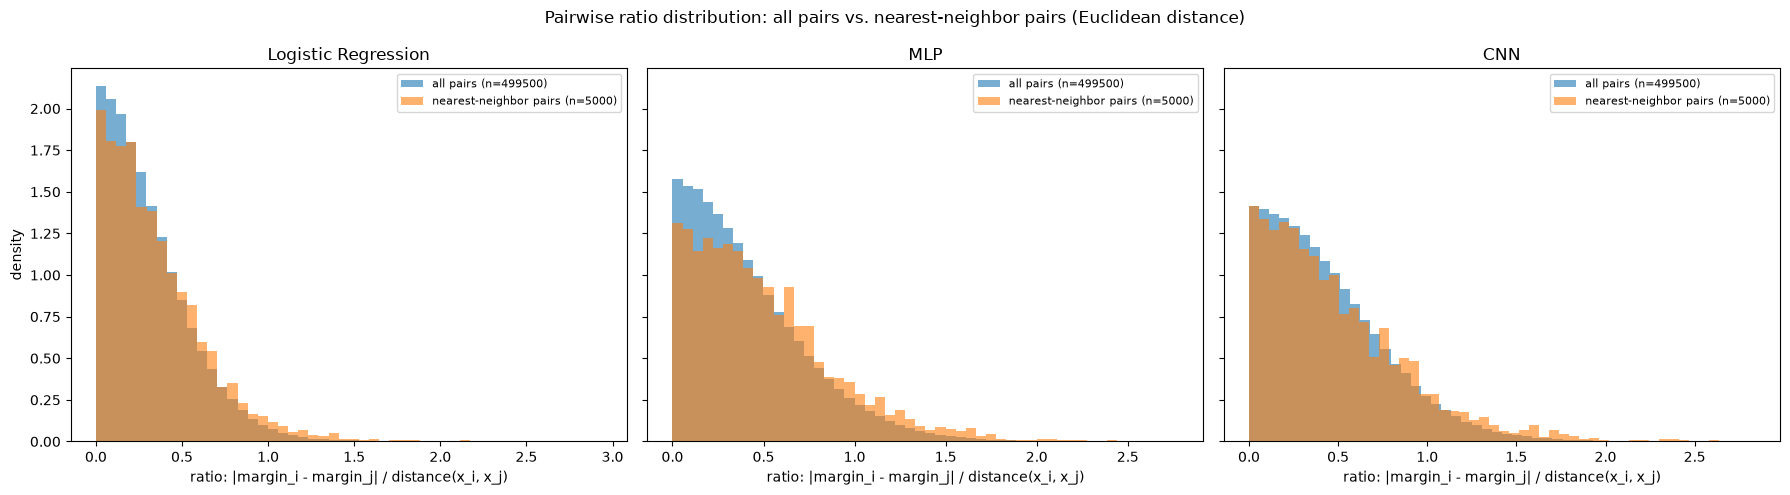

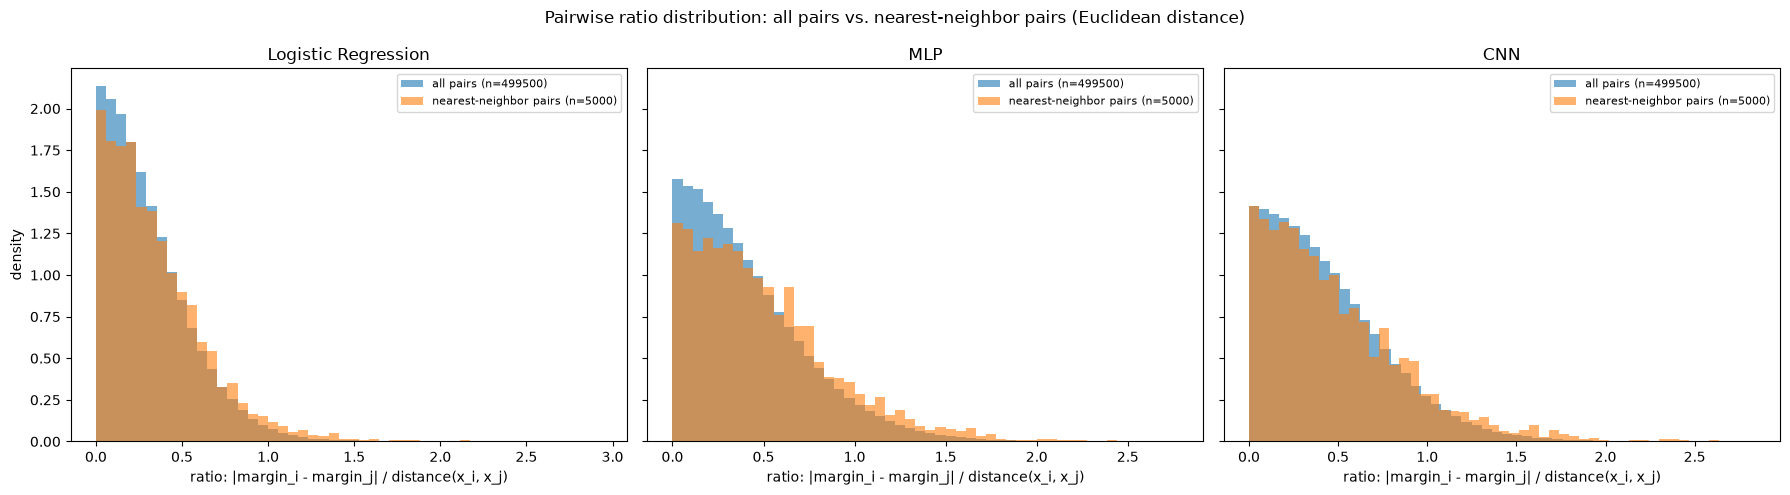

In [11]:
import numpy as np

print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_euclidean_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist = plots.plot_ratio_distribution(
    ratio_dist_euclidean_results, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution.png")
display(fig_ratio_dist)

## Highest-ratio near-neighbour pairs

The specific image pairs driving the upper tail of each model's
near-neighbour distribution above -- two pixel-similar digits that
model's margin treats very differently, the exact combination a
local-Lipschitz diagnostic is meant to flag. One gallery per model, shown
separately rather than as subplot panels on one figure (6 pairs x 2
images already fills a figure; three side by side would make each image
too small to actually look at). Each image is labeled with its true and
predicted class and the pair's ratio, deduplicated so a mutual
nearest-neighbour pair only counts once. The printed table also breaks
each ratio into the two components it's built from -- `dist` (the
denominator, distance between the pair) and `|margin_diff|` (the
numerator, absolute margin difference) -- so a high ratio driven by an
unusually small distance can be told apart from one driven by an
unusually large margin swing.

**Finding**: the MLP and CNN's top pairs are genuine cross-digit
confusions, not degenerate or nonsensical matches, and differ by model --
MLP's top 3 are 2/3, 6/5, 3/3; the CNN's are 6/5, 4/9, 2/6. Logistic
regression's top pairs are a different pattern, though: 5 of its top 6
are the *same* digit, "1" vs. "1" (four of those five sharing one image,
test index 5642, as a common member) -- a same-digit high-ratio pattern,
not a cross-digit-confusion one, closer to what the higher-capacity CNN's
"1/1" pairs show in the label-error-cross-reference section further down
than to a decision-boundary story.

*(These specific pairs are sensitive to `n_lipschitz_points`, which sizes
the query set excluded from this near-neighbour subset -- see the
"Validity check" section further down for a documented instance of this
sensitivity and its root cause.)*

=== logistic_regression ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      1      5      1      1   2.9369   6.3274        18.5828
   1      1      5      1      1   2.5402   6.2913        15.9811
   2      1      5      1      1   2.4927   6.4059        15.9678
   3      5      5      1      5   2.1507   6.5864        14.1655
   4      1      5      1      1   2.1411   6.4469        13.8036
   5      3      3      3      8   1.8617   7.8491        14.6126


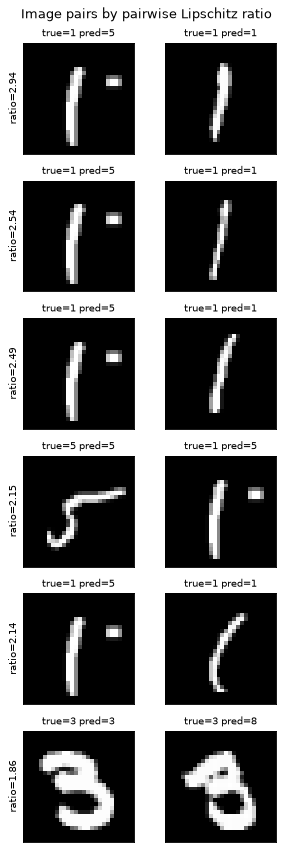

=== mlp ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      2      2      3      2   2.7766   8.3542        23.1962
   1      6      5      5      5   2.6147   7.0113        18.3328
   2      3      3      3      5   2.4233   7.0934        17.1896
   3      8      0      0      0   2.2856   8.5718        19.5914
   4      3      8      8      8   2.2490   8.1332        18.2914
   5      1      5      1      1   2.2326   6.2913        14.0459


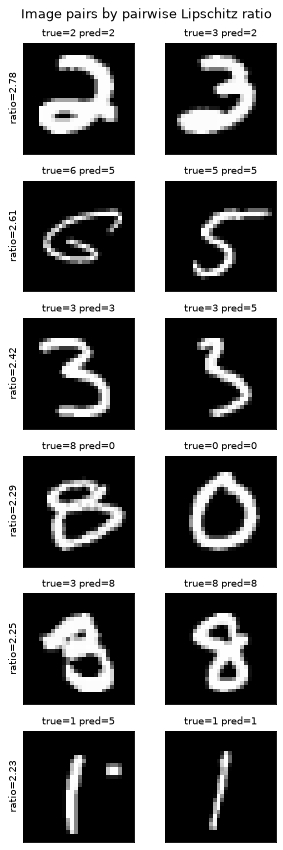

=== cnn ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      6      5      5      5   2.8021   7.0113        19.6462
   1      4      4      9      7   2.5869   5.9099        15.2883
   2      2      2      6      4   2.4105   6.6745        16.0888
   3      5      5      8      5   2.4050   7.8547        18.8909
   4      0      0      2      0   2.3630   6.0050        14.1897
   5      6      6      6      6   2.3519   5.9287        13.9437


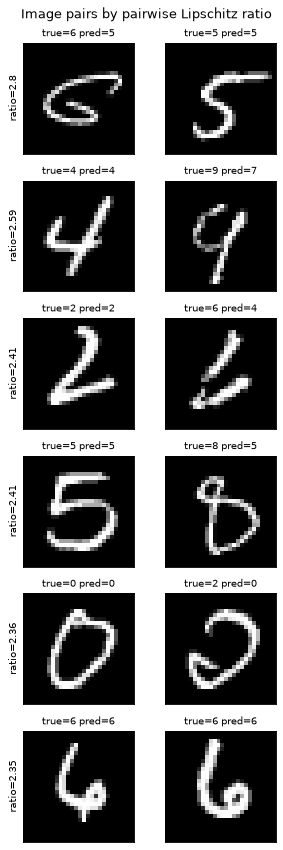

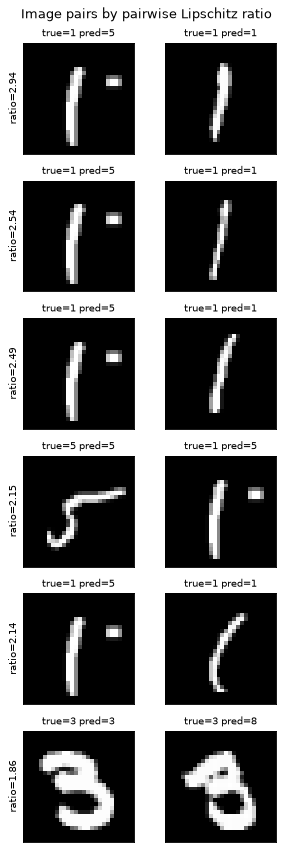

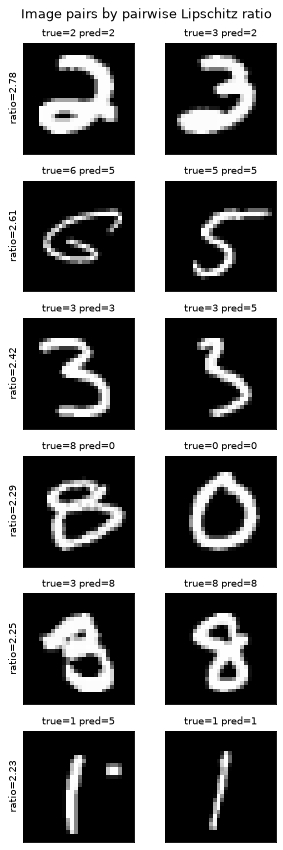

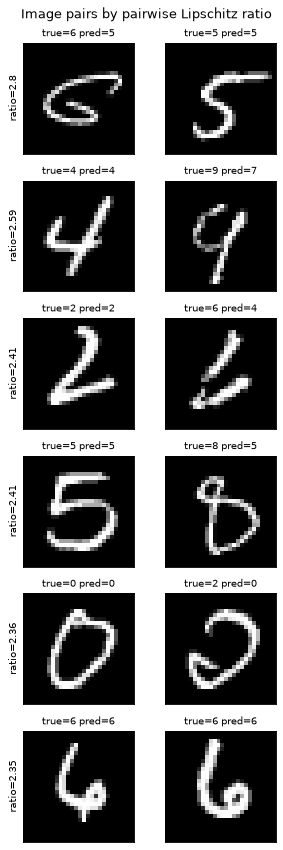

In [12]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_euclidean_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}{'dist':>9}{'|margin_diff|':>15}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio, dist, margin_diff) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}{dist:>9.4f}{margin_diff:>15.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_{name}.png")
    display(fig)

## Mahalanobis distance: does it change the ratio-distribution picture?

Same question as [Mahalanobis vs. Euclidean: does the metric change the
estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
earlier in this notebook, now applied to the ratio-distribution/
near-neighbour checkpoint instead of the three sub-method estimates. Same
three models, same stratified 1000-point subset, same 5-nearest-neighbour
pairs (found in raw pixel space, so the neighbour structure itself doesn't
change -- only the ratio's denominator does), reusing the epsilon/precision
already selected above rather than re-running epsilon selection.

In [13]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 4b).
ratio_dist_mahalanobis_results = results["ratio_dist_mahalanobis_results"]

## Does the distribution shift near neighbours under Mahalanobis?

Under Euclidean distance (above), near-neighbour pairs sat modestly
*above* the full distribution for every model. Checked here, not assumed:
does the same hold under Mahalanobis, or does a metric derived from the
data's own pixel covariance behave differently?

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    1.2492    0.1389    0.1136    0.1120
logistic_regression   near-neighbour         (5000,)    0.0001    1.0980    0.1078    0.0857    0.0933
mlp                   all pairs            (499500,)    0.0000    1.1762    0.1870    0.1550    0.1458
mlp                   near-neighbour         (5000,)    0.0000    0.9965    0.1537    0.1261    0.1233
cnn                   all pairs            (499500,)    0.0000    1.1682    0.1983    0.1694    0.1481
cnn                   near-neighbour         (5000,)    0.0001    0.8452    0.1508    0.1190    0.1249


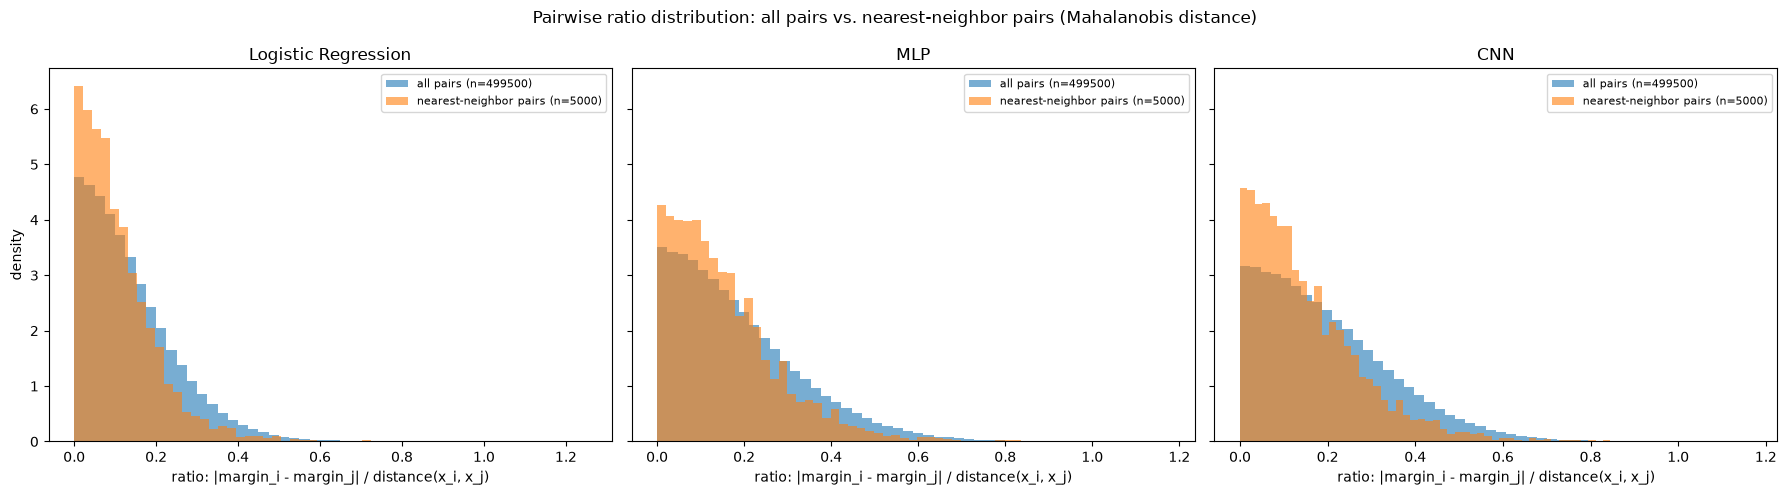

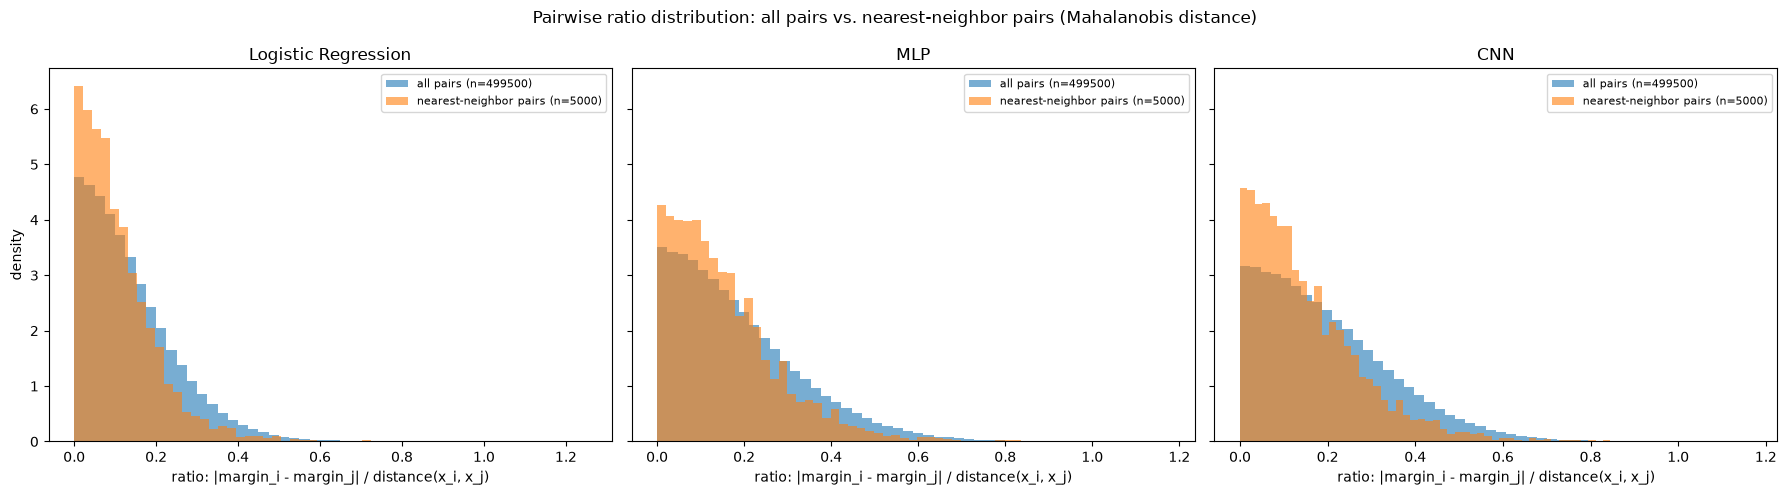

In [14]:
print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_mahalanobis_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist_mahalanobis = plots.plot_ratio_distribution(
    ratio_dist_mahalanobis_results, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_mahalanobis.png")
display(fig_ratio_dist_mahalanobis)

## Highest-ratio near-neighbour pairs (Mahalanobis)

Same gallery layout as the Euclidean version above, now for the
Mahalanobis distance. The absolute ratio values are much smaller here
(consistent with the Mahalanobis-vs-Euclidean sub-method comparison
earlier in this notebook, where every Mahalanobis estimate was smaller
too) -- the interesting comparison is *which* pairs and *what pattern*
show up, not the raw numbers, which aren't on the same scale as the
Euclidean ones.

=== logistic_regression (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      1      5      1      1   1.0980  16.9239        18.5828
   1      1      5      1      1   0.9431  16.9321        15.9678
   2      1      5      1      1   0.8951  17.8533        15.9811
   3      1      5      1      1   0.8019  17.2146        13.8036
   4      1      5      5      5   0.7188  19.7083        14.1655
   5      3      2      2      2   0.6400  21.0524        13.4745


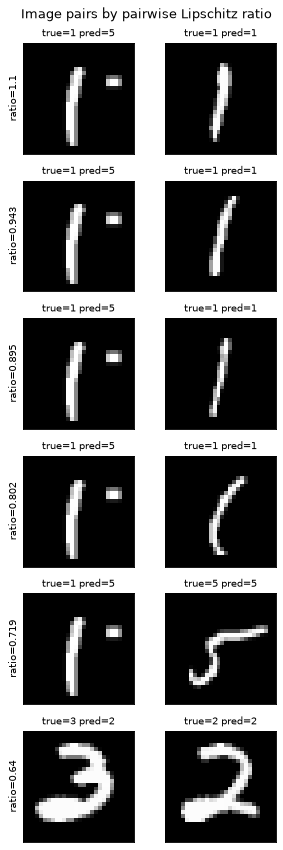

=== mlp (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      2      2      3      2   0.9965  23.2777        23.1962
   1      1      5      1      1   0.8326  16.9239        14.0905
   2      1      5      1      1   0.8182  16.9321        13.8533
   3      3      3      3      5   0.8087  21.2565        17.1896
   4      8      0      0      0   0.8065  24.2908        19.5914
   5      1      5      1      1   0.7867  17.8533        14.0459


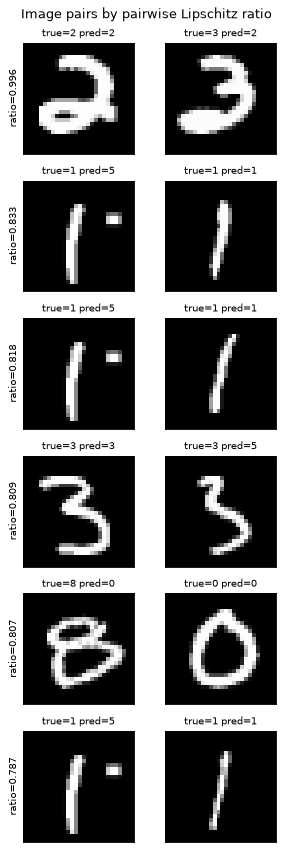

=== cnn (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio     dist  |margin_diff|
   0      4      4      9      7   0.8452  18.0873        15.2883
   1      6      5      5      5   0.8190  23.9895        19.6462
   2      8      5      5      5   0.8095  23.3378        18.8909
   3      3      3      3      3   0.7734  21.2565        16.4401
   4      6      4      2      2   0.7471  21.5336        16.0888
   5      2      0      0      0   0.7323  19.3772        14.1897


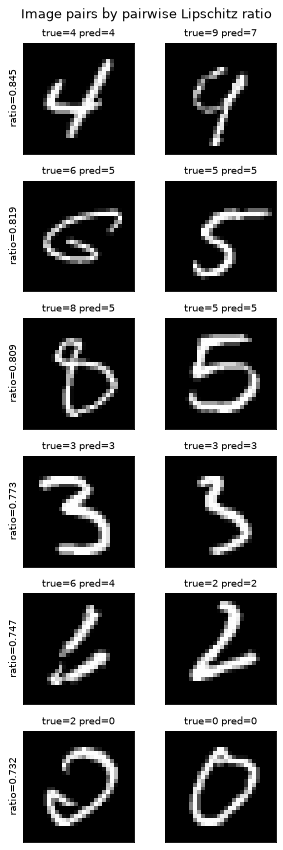

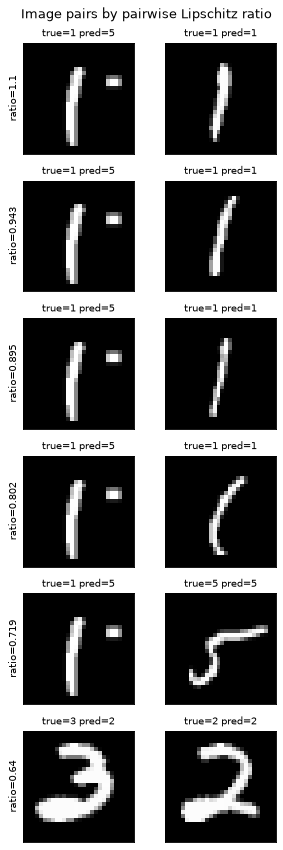

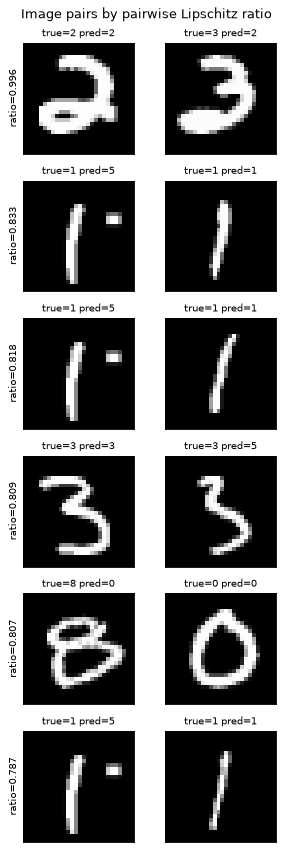

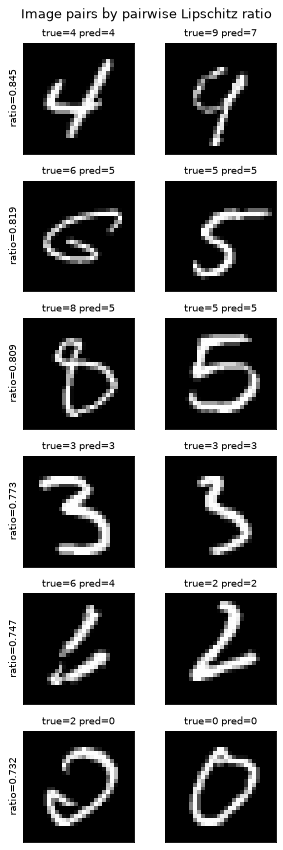

In [15]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_mahalanobis_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} (Mahalanobis) ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}{'dist':>9}{'|margin_diff|':>15}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio, dist, margin_diff) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}{dist:>9.4f}{margin_diff:>15.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_mahalanobis_{name}.png")
    display(fig)

## Euclidean vs. Mahalanobis: does the metric change which pairs matter?

The same comparison as [Mahalanobis vs. Euclidean: does the metric change
the estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
above, but for the ratio-distribution summary stats instead of the three
sub-method estimates.

**Finding, and it's the opposite of what the earlier panels in this
notebook might suggest by analogy**: under Euclidean distance,
near-neighbour pairs sit *above* the full distribution's mean for every
model (a 13-23% increase). Under Mahalanobis distance, that flips --
near-neighbour pairs sit *below* the full distribution's mean for every
model (a 14-21% decrease). This reversal is consistent across all three
models, not a one-off:

| model | Euclidean near/all mean ratio | Mahalanobis near/all mean ratio |
|---|---|---|
| logistic regression | 1.13 | 0.79 |
| MLP | 1.23 | 0.86 |
| CNN | 1.17 | 0.81 |

One plausible explanation, not confirmed here: the Mahalanobis distance
derives its notion of "closeness" from MNIST's own pixel covariance, so
directions where pixels vary a lot across the whole dataset count as
"large" steps and directions where they barely vary count as "small"
steps. Two images that are close together in raw pixel space
(near-neighbours) likely differ mainly along exactly those
high-variance, commonly-varying directions -- so their Mahalanobis
distance grows disproportionately relative to their Euclidean distance,
shrinking the ratio. This is the same kind of self-referential-metric
effect flagged in Experiment 1 (a metric built from the data's own
variance structure can end up dividing out part of the very signal it's
used to measure) -- worth keeping in mind rather than assuming the
Mahalanobis distance is a strict upgrade here just because it improved
things elsewhere in this notebook.

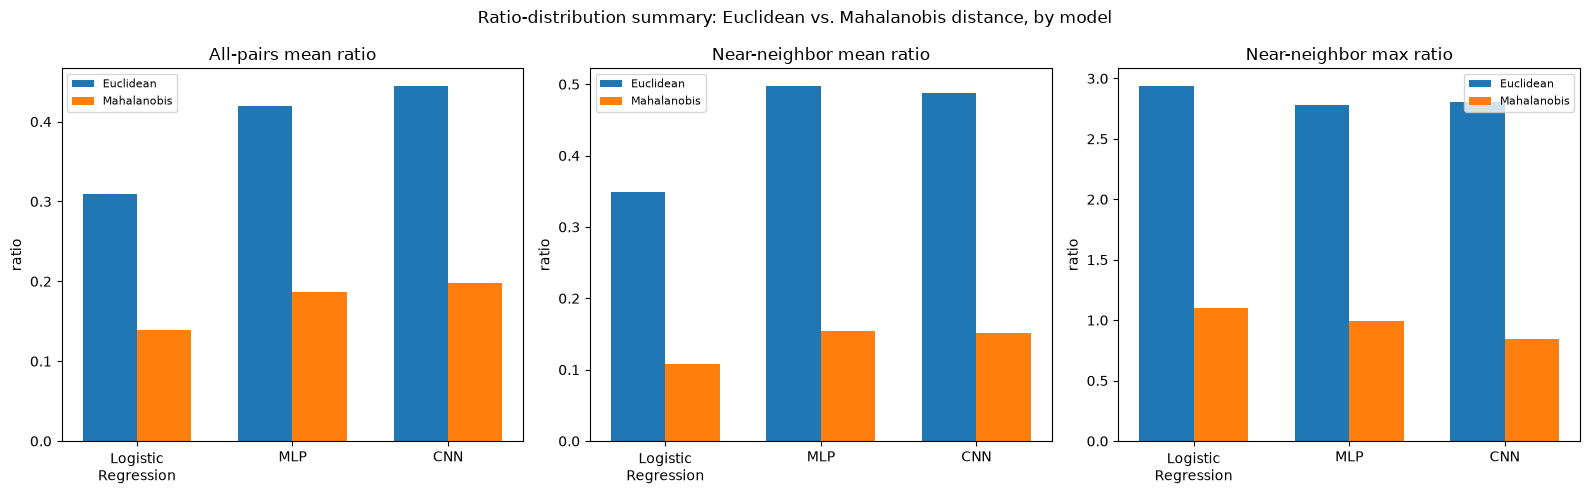

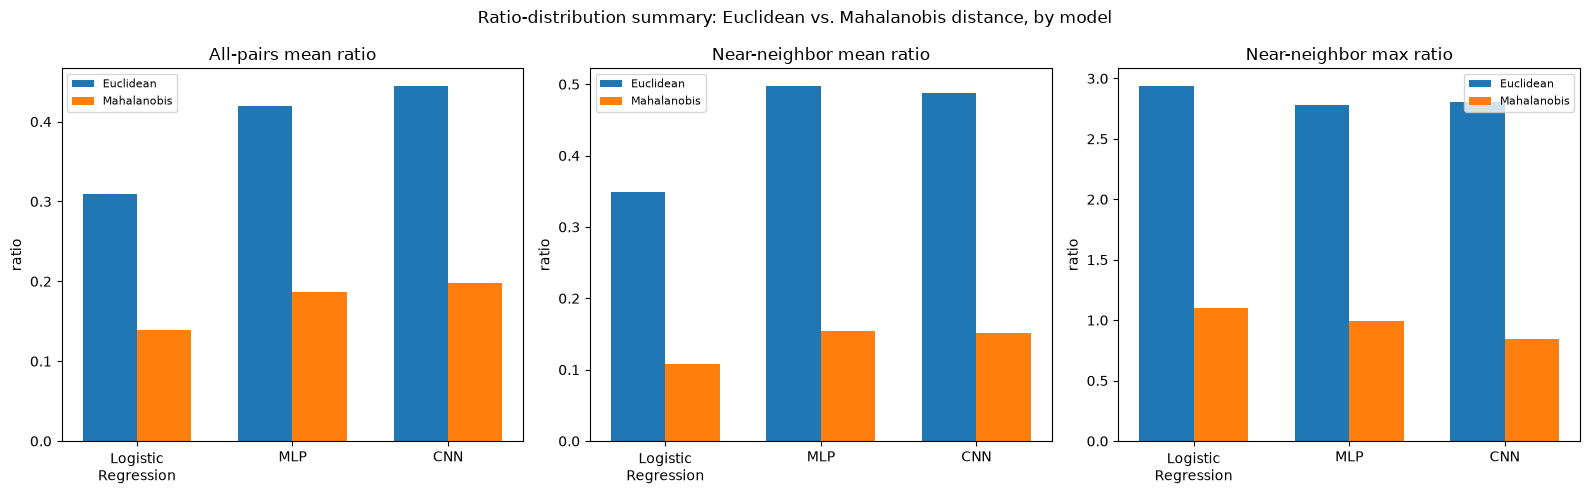

In [16]:
fig_ratio_dist_compare = plots.plot_ratio_distribution_euclidean_vs_mahalanobis(
    ratio_dist_euclidean_results, ratio_dist_mahalanobis_results,
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_euclidean_vs_mahalanobis.png")
display(fig_ratio_dist_compare)

## Embedding-space Mahalanobis distance: does the embedding degree matter?

Everything above fits the Mahalanobis metric's covariance directly in raw 784-pixel space.
`embeddings.py::elementwise_embedding(x, degree)` maps each pixel through `[x, x**2, ..., x**degree]`
(784*degree dimensions, no cross-pixel terms -- the same convention `toy_lipschitz` uses), letting
the metric instead be fit in a higher-dimensional embedded feature space.

This exercises a code path that used to fail outright: fitting a precision matrix on an embedded
space and pairing it with an embedded gradient requires threading `embed_fn` through both
`epsilon_stability_check` and `gradient_norm_estimate`'s dual-norm computation, which used to assume
the precision matrix and the raw-pixel gradient always had matching dimensions. `run_embedding_degree_sweep`'s
`degree=1` result (the identity embedding) is checked directly against the pre-existing raw-pixel
pipeline in `tests/test_epsilon_selection.py::test_run_embedding_degree_sweep_degree_1_matches_raw_pixel_baseline`
before trusting `degree > 1`, where there's no raw-pixel result left to compare against.

This repeats epsilon selection (on a fixed 3000-point pool) and the ratio-distribution analysis
(fit on the full 60k training set) once per degree in `{1, 2, 3}`, using logistic regression as the
reference model throughout. It's markedly slower than the rest of this notebook -- an SVD of a
`(60000, 2352)` matrix at degree=3, repeated across every degree -- and is deliberately **not** part
of `run_mnist_experiment()`/`main()`.

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=1          mean L_hat=8.7099  std=0.0887  cv=0.0102


  epsilon=10         mean L_hat=26.3820  std=0.1695  cv=0.0064


  epsilon=100        mean L_hat=82.0134  std=0.7194  cv=0.0088
selected epsilon=0.01 (smallest meeting cond<=10000, cv<=0.05)


  [embedding_degree3/logistic_regression] all-pairs ratio:        mean=0.1097  max=0.7267  n=499500
  [embedding_degree3/logistic_regression] near-neighbor ratio:     mean=0.0805  max=0.6844  n=5000



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results


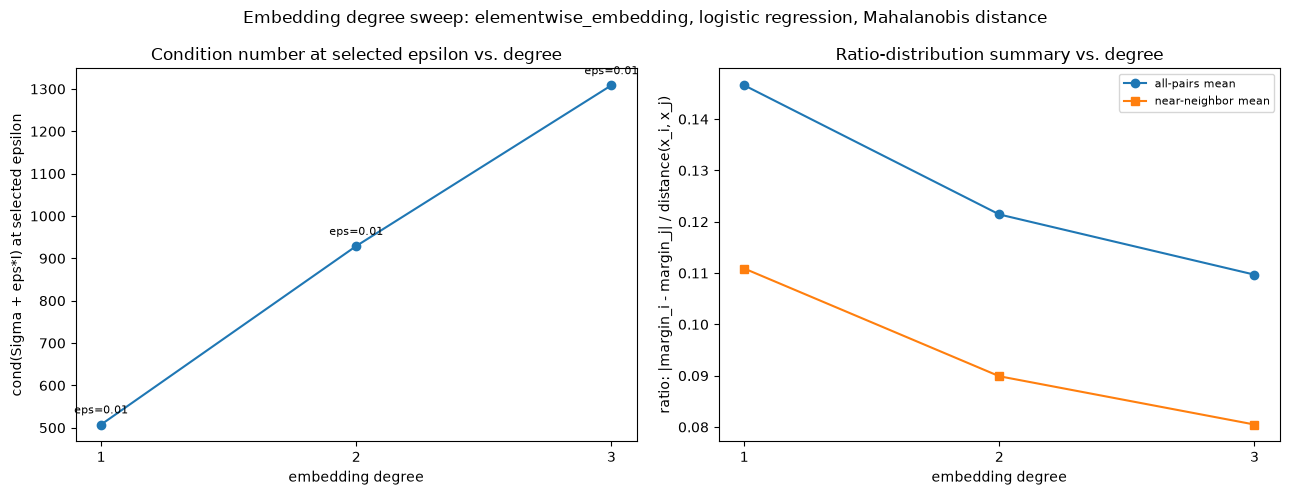

In [17]:
embedding_sweep = run_experiment.run_embedding_degree_sweep(degrees=(1, 2, 3))

In [18]:
import pandas as pd

embedding_sweep_df = pd.DataFrame([
    {
        "degree": degree,
        "selected_epsilon": r["selected_epsilon"],
        "cond_number": r["cond_number_at_selected_epsilon"],
        "all_pairs_mean": r["ratio_summary"]["all_pairs_mean"],
        "near_neighbor_mean": r["ratio_summary"]["near_neighbor_mean"],
    }
    for degree, r in embedding_sweep["degree_results"].items()
])
embedding_sweep_df

,degree,selected_epsilon,cond_number,all_pairs_mean,near_neighbor_mean
0,1,0.01,507.663978,0.146585,0.110887
1,2,0.01,929.166776,0.121418,0.089892
2,3,0.01,1308.605022,0.109687,0.080485


**Result:** the selected epsilon stays `0.01` at every degree tested, while the condition number
at that epsilon grows roughly with the embedded dimension (`508 -> 929 -> 1309` for degree `1/2/3`).
Both ratio-distribution summary stats shrink monotonically as the embedding degree increases --
all-pairs mean `0.146 -> 0.121 -> 0.110`, near-neighbor mean `0.111 -> 0.090 -> 0.080`. This looks
like a pure scale effect, not a structural or locality one: the near-neighbor mean stays *below*
the all-pairs mean at every degree tested -- the same reversal already established at degree=1
under plain Mahalanobis distance (see [Results](#Results) above) -- so raising the embedding degree
shrinks the ratio's overall scale without changing *which* pairs (visually-similar vs. general)
are more or less sensitive relative to each other.

## Higher-capacity CNN: StrongCNN results (from a previous run)

A follow-up to the CNN baseline above: `models.py::StrongCNN` (batch norm, dropout, light
rotation/translation augmentation, a cosine-annealed learning rate, more epochs) trained on the
same *raw* (uncleaned) MNIST train/test split, as a stronger baseline ahead of a later
data-cleaning experiment.

**This section loads and displays an already-completed run -- it does not retrain anything here.**
The 25-epoch training run, its checkpoint, and its full Lipschitz/ratio-distribution results
already exist in `results/stronger_cnn_raw_mnist/`
(`run_experiment.py::run_stronger_cnn_raw_mnist_experiment`, not part of `main()`/the
`run_mnist_experiment()` call above). This is just one place to see those results alongside
everything else in this notebook, without going back to a terminal.

In [17]:
import json

with open(run_experiment.RESULTS_DIR / "stronger_cnn_raw_mnist" / "stronger_cnn_raw_mnist_results.json") as f:
    strong_cnn_results = json.load(f)

original_cnn_test_acc = results["accuracies"]["cnn"]["test"]
strong_cnn_test_acc = strong_cnn_results["accuracies"]["cnn"]["test"]

print(f"Original SmallCNN  test_acc={original_cnn_test_acc:.4f}")
print(f"StrongCNN          test_acc={strong_cnn_test_acc:.4f}")
print(f"delta: {(strong_cnn_test_acc - original_cnn_test_acc) * 100:+.2f} percentage points")

import pandas as pd

strong_cnn_ratio_df = pd.DataFrame([
    {"metric": metric, **strong_cnn_results["ratio_distribution_analysis"][f"{metric}_cnn"]}
    for metric in ["euclidean", "mahalanobis"]
]).set_index("metric")
strong_cnn_ratio_df

Original SmallCNN  test_acc=0.9865
StrongCNN          test_acc=0.9966
delta: +1.01 percentage points


,all_pairs_mean,all_pairs_max,near_neighbor_mean,near_neighbor_max,n_all_pairs,n_near_neighbor_pairs
metric,,,,,,
euclidean,0.387895,3.14295,0.463367,3.142950,499500,5000
mahalanobis,0.172216,1.12965,0.143166,1.026928,499500,5000


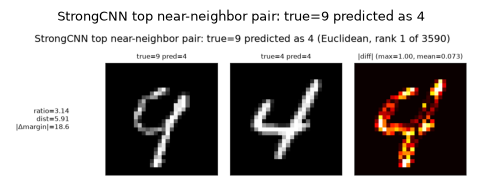

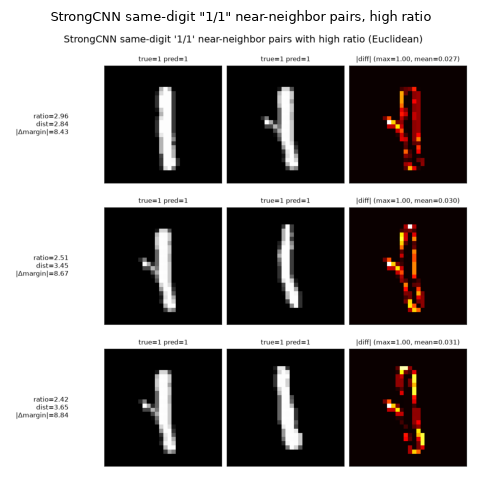

In [18]:
# Loaded from the already-saved PNGs (built from the already-saved near-neighbor
# arrays in a previous run) rather than regenerated -- regenerating would need the
# checkpoint loaded and the same query points reconstructed identically.
strong_cnn_dir = run_experiment.RESULTS_DIR / "stronger_cnn_raw_mnist"

for fname, title in [
    ("pair_diagnostic_9_4.png", "StrongCNN top near-neighbor pair: true=9 predicted as 4"),
    ("pair_diagnostic_1_1_pairs.png", "StrongCNN same-digit \"1/1\" near-neighbor pairs, high ratio"),
]:
    img = plt.imread(strong_cnn_dir / fname)
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(6, 6 * h / w))
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    plt.show()

## Validity check: are the flagged near-neighbor pairs just mislabeled examples?

A high-ratio near-neighbor pair (a large margin swing for a small pixel distance) is exactly what
a *mislabeled* example would also produce, not just a genuinely sensitive model. This section
cross-references every flagged pair discussed in this notebook (and the StrongCNN section above)
against [cleanlab/label-errors](https://github.com/cleanlab/label-errors)'s published,
mTurk-verified MNIST test-set label corrections (15 confirmed errors out of 10,000 test images) --
`data/known_label_errors_mnist_test.json`. This is a cross-reference of already-computed indices
only: no retraining, no dataset modification, no near-neighbor search recomputed here.

In [2]:
import json

import pandas as pd

with open(run_experiment.RESULTS_DIR.parent / "data" / "known_label_errors_mnist_test.json") as f:
    known_label_errors = json.load(f)
with open(run_experiment.RESULTS_DIR / "label_error_crossref.json") as f:
    crossref = json.load(f)

print(f"known confirmed MNIST test-set label errors: {known_label_errors['n_confirmed_errors']} "
      f"(of {known_label_errors['n_candidates_reviewed']} candidates reviewed)")

crossref_df = pd.DataFrame([
    {
        "group": row["group"],
        "pair": row["pair"],
        "match to known label error": (
            "n/a" if row["known_label_error"] is None
            else ("yes" if row["known_label_error"] else "no")
        ),
    }
    for row in crossref["rows"]
])
display(crossref_df)

print()
print(f"Conclusion: {crossref['conclusion']}")

known confirmed MNIST test-set label errors: 15 (of 100 candidates reviewed)


,group,pair,match to known label error
0,Original CNN (weaker),6/5,no
1,Original CNN (weaker),4/9,no
2,Original CNN (weaker),2/6,yes
3,Original CNN (weaker),8/5,no
4,Original CNN (weaker),2/0,no
5,Original CNN (weaker),6/6,no
6,Original logistic regression,1/1,no
7,Original logistic regression,1/1,no
8,Original logistic regression,1/1,no
9,Original logistic regression,5/1,no



Conclusion: Of all 22 checked pairs across all four model/run groups, only one involves a known label error: the original CNN's current rank-3 pair (test index 9679). Every other pair -- including all of logistic regression's top pairs, which are almost entirely same-digit '1/1' pairs -- is clean, supporting genuine model behavior over labeling artifacts as the general pattern, with one confirmed exception.


**Root cause of the earlier provenance mismatch (now resolved)**: the original CNN's "8/2"/"8/0"
pairs and logistic regression's "0/7", previously named in this notebook's own "Highest-ratio
near-neighbour pairs" commentary, were generated when `run_mnist_experiment`'s `n_lipschitz_points`
parameter defaulted to **300** (commit `4db5ae9`, 2026-08-12). The very next day, commit `48bd088`
("Add covariance eigenvalue spectrum plot to mnist_lipschitz", 2026-08-13) changed that default to
**1000**, with no update to the near-neighbour-pairs commentary to match. `n_lipschitz_points`
sizes `query_idx` (the Lipschitz sub-method estimators' query set), which is passed as
`exclude_idx` into the ratio-distribution analysis's stratified near-neighbour subset draw -- so
even with an identical seed, a different `exclude_idx` produces a different subset, and therefore
different near-neighbour pairs. Model training itself is untouched by this parameter and remains
bit-for-bit reproducible (accuracy numbers from rerunning this notebook match `README.md`'s
documented table exactly). This is genuine stale documentation from a superseded parameter
default, confirmed via `git log -S` on `run_experiment.py` and by rerunning the current codebase at
the documented seed -- not file corruption, and not non-determinism. The "Highest-ratio
near-neighbour pairs" section above and `results/label_error_crossref.md` now reflect the current,
reproducible pairs; the old "8/2"/"8/0"/"0/7" claims have been retired from both.

**The positive finding this surfaced, reframed now that it's understood**: the CNN's actual
current rank-3 highest-ratio near-neighbour pair (Euclidean) is **6 vs. 2** (test indices 9679 and
2200, ratio 2.41) -- and index **9679 is itself a confirmed known label error** (original label
"6", rejected by a majority of mTurk workers, though without a single agreed-on replacement label).
This is a positive result, not a caveat: direct, independent evidence that this project's
near-neighbour diagnostic can surface genuine *labeling* problems in MNIST's own test set, not just
model confusions -- the same kind of real, interpretable failure the near-neighbour checkpoint was
built to catch, just from an unexpected source. See `results/label_error_crossref.md` for the full
write-up, including the complete current top-6 table for all three original models.

## Summary and status

See `README.md` in this folder for the full write-up, including the
actual measured numbers behind the plots above, the design decisions made
along the way (activation choice, pair-sampling strategy, the precision
vs. its inverse convention in the gradient-norm dual norm, why ridge
regularization was used before trying PCA truncation, how epsilon was
selected), and an honest account of what was and wasn't expected --
including that the three sub-methods agree much less closely here than
they did in Experiment 1's toy setting, and that this gap widens rather
than narrows under the Mahalanobis metric. The ratio-distribution
checkpoint extends that same honesty: under Euclidean distance,
near-neighbour pairs sit modestly *above* the full distribution for all
three models. The MLP and CNN's top pairs are genuine cross-digit
confusions (MLP: 2/3, 6/5, 3/3; CNN: 6/5, 4/9, 2/6); logistic regression's
are mostly same-digit "1 vs. 1" pairs instead -- see the note further up
this notebook and `results/label_error_crossref.md` for why these
specific pairs differ from earlier documentation, and for a positive
finding this discrepancy led to: the CNN's actual rank-3 pair (test index
9679) turns out to involve one of MNIST's own confirmed test-set label
errors, direct evidence the near-neighbour diagnostic can catch labeling
problems too, not just model confusions. Under Mahalanobis distance, the
near-vs-all relationship *reverses* -- near-neighbour pairs sit *below*
the full distribution for all three models, plausibly because the
Mahalanobis metric's own covariance-derived notion of "large step"
already accounts for the directions along which visually-similar images
tend to differ (the same self-referential-metric caution Experiment 1
raised). Both distances and all three models are now covered for this
checkpoint.

The embedding-degree sweep above extends this picture one step further:
raising `elementwise_embedding`'s degree (fitting the Mahalanobis metric
in a higher-dimensional feature space rather than raw pixel space)
shrinks the ratio-distribution statistics monotonically, but the
near-vs-all-pairs reversal already established at degree=1 holds at
every degree tested -- a scale effect layered on top of the metric-choice
effect above, not a separate or contradictory finding.

This is Experiment 2 of the Lipschitz-diagnostics project. Adversarial
examples, robustness mitigations, and Fashion-MNIST are explicitly out of
scope here and may be the subject of a later experiment.